# Steam Game Pricing Analysis
## The Importance of Price!
A Pricing Optimization Analysis by Anubad Mahapatra<br>
Available on GitHub

## Preliminary Steps
### Imports
For this project we will be using:
* `pandas` for data manipulation and analysis
* `numpy` for numerical operations
* `re` for regex string cleaning
* `os` for filepath and directory management
* `datasets` for loading the raw dataset from HuggingFace
* `dotenv` for managing environment variables
* `scikit-learn` for the machine learning tasks (preprocessing, Random Forest model, evaluation)
* `matplotlib`'s `pyplot` and `ticker` for custom visualizations and axis formatting
* `seaborn` for statistical dta visualization
* `warnings` to suppress warnings that could ruin output

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import re
import os
from dotenv import load_dotenv
from datasets import load_dataset
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import warnings

# Keeps the output clean from deprecation warnings
warnings.filterwarnings('ignore')

### Load the Dataset
The dataset is found on *HuggingFace* but a local copy is saved so that each rerun does not necessitate a long download process. This process does *not* check for changes in the dataset, so for updated data, the csv file that is saved must be deleted so that a fresh copy can be downloaded. This project utilizes a comprehensive dataset of Steam store listings, providing a detailed look at the commercial performance and metadata of thousands of titles.

Dataset Overview
The data is retrieved using the datasets library and captures a wide array of variables essential for market analysis:

* **Identity & Metadata**: Includes the unique appID and the official name of each title.
* **Commercial Features**: Contains the current price of the software and estimated_owners (represented as numerical ranges), which serve as the primary inputs for calculating revenue.
* **Engagement Metrics**: Provides technical performance data such as peak_ccu (Peak Concurrent Users) and median_playtime_forever, which help distinguish active, successful titles from "dead" games.
* **Classification**: Includes the genres column, which we refined to isolate specific gaming categories from professional software and utility applications.

By loading this data, we can move from raw storefront information to a structured format suitable for feature engineering and predictive modeling.

In [2]:
print("=== Steam Games Pricing Analysis ===")

# Define where we want to save our local copy
data_dir = "data"
local_file_path = os.path.join(data_dir, "steam_games_raw.csv")

# Create the data directory if it doesn't exist yet
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

try:
    # 1. Check if we already downloaded the data previously
    if os.path.exists(local_file_path):
        print(f"[1/2] Found local dataset at '{local_file_path}'. Loading from disk...")
        df = pd.read_csv(local_file_path)
        print("[2/2] Local data loaded instantly!\n")
        
    else:
        # 2. If no local copy exists, download from Hugging Face
        print("[1/4] Local copy not found. Loading environment variables...")
        load_dotenv()
        hf_token = os.getenv("HF_TOKEN")

        print("[2/4] Initializing connection to Hugging Face...")
        ds = load_dataset("FronkonGames/steam-games-dataset", split="train", token=hf_token)
        
        print("[3/4] Dataset downloaded! Converting to pandas DataFrame...")
        df = pd.DataFrame(ds)
        
        print(f"[4/4] Saving a local copy to '{local_file_path}' for future runs...")
        # Save to CSV so we can load it locally next time
        df.to_csv(local_file_path, index=False)
        print("Save complete!\n")
except Exception as e:
    print("\n[ERROR] Failed to load the dataset!")
    print(f"Error Details: {e}")
    print("\nTroubleshooting Tips:")
    print("1. If using Hugging Face: Check if your .env file is formatted exactly as: HF_TOKEN=your_token")
    print("2. Check your internet connection.")

=== Steam Games Pricing Analysis ===
[1/2] Found local dataset at 'data/steam_games_raw.csv'. Loading from disk...
[2/2] Local data loaded instantly!



### The Dataset
Let's identify some key points of concern in the dataset:

1. Show the **row** and **column** count of the dataset
2. Check for **missing** values
3. Check for **duplicate** entries

In [3]:
# 1. Basic Structure
print("\n--- Dataset Info ---")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print("\nColumn Names:")
for col_name in df.columns:
    print(f"- {col_name}")

# 2. Check for missing values (Nulls/NaNs)
print("\n--- Missing Values ---")
missing_data = df.isnull().sum()
missing_data_gt_0 = missing_data[missing_data > 0]
if len(missing_data_gt_0) > 0:
    print(missing_data_gt_0) # Only show columns with missing data
else:
    print("Missing Values: 0")

# 3. Check for Duplicate entries
# AppID is the unique identifier for a game on Steam
duplicate_count = df.duplicated(subset=['appID']).sum()
print(f"\n--- Duplicates ---")
print(f"Duplicate games found: {duplicate_count}")

# Look at the first 3 rows to confirm it loaded correctly
df.head(3)


--- Dataset Info ---
Total Rows: 124146
Total Columns: 41

Column Names:
- appID
- name
- release_date
- estimated_owners
- peak_ccu
- required_age
- price
- dlc_count
- detailed_description
- short_description
- supported_languages
- full_audio_languages
- reviews
- header_image
- website
- support_url
- support_email
- windows
- mac
- linux
- metacritic_score
- metacritic_url
- user_score
- positive
- negative
- score_rank
- achievements
- recommendations
- notes
- average_playtime_forever
- average_playtime_2weeks
- median_playtime_forever
- median_playtime_2weeks
- developers
- publishers
- categories
- genres
- tags
- screenshots
- movies
- packages

--- Missing Values ---
name                         1
detailed_description      8428
short_description         8315
reviews                 112022
header_image                81
website                  74081
support_url              69463
support_email            22429
metacritic_url          119889
score_rank              124106
no

,appID,name,release_date,estimated_owners,peak_ccu,required_age,price,dlc_count,detailed_description,short_description,...,median_playtime_forever,median_playtime_2weeks,developers,publishers,categories,genres,tags,screenshots,movies,packages
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,NaN,NaN,...,0,0,[],[],[],[],[],['https://shared.akamai.steamstatic.com/store_...,[],[]
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,0,"Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",...,8,0,['minori'],['MangaGamer'],"['Single-player', 'Steam Trading Cards', 'Stea...",['Adventure'],[],['https://shared.akamai.steamstatic.com/store_...,[],"[{""title"": ""Buy Supipara - Chapter 1 Spring Ha..."
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,"Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,...,0,0,['Somer Games'],['8floor'],"['Single-player', 'Family Sharing']",['Casual'],[],['https://shared.akamai.steamstatic.com/store_...,[],"[{""title"": ""Buy Mystery Solitaire The Black Ra..."


### Preprocessing
1. Remove duplicate entries.
2. Remove games with missing names
3. Replace the range of values for `estimated_owners` to the midpoint value.
4. Calculate revenue by multiplying the game's price by its estimated owners.
5. Filter out free-to-play games (price = $0) since their microtx model does not fit a standard game model.
6. Find non-game titles that are actually professional software that is included in steam's lineup.

In [4]:
print("--- Starting Preprocessing & Feature Engineering ---")

# Save a copy of the raw data before modifications just in case
df_raw = df.copy()

# Task 1. Remove duplicate entries based on the unique appID
initial_rows = len(df)
df = df.drop_duplicates(subset=['appID'], keep='first')
print(f"1. Removed {initial_rows - len(df):,} duplicate entries.")

# Task 2. Remove games with missing names
current_rows = len(df)
df = df.dropna(subset=['name'])
print(f"2. Removed {current_rows - len(df):,} games with missing names.")

# Task 3. Replace the range of values for 'estimated_owners' to the midpoint value
def parse_owners(owner_str):
    if pd.isna(owner_str) or owner_str == '0 - 0':
        return 0
    # Extract numbers from strings like '20000 - 50000'
    numbers = [int(s) for s in re.findall(r'\d+', str(owner_str))]
    if len(numbers) == 2:
        return sum(numbers) / 2
    return numbers[0] if numbers else 0

df['owners_midpoint'] = df['estimated_owners'].apply(parse_owners)
print("3. Converted 'estimated_owners' ranges to midpoint values.")

# Task 4. Create our Revenue Proxy
df['est_revenue'] = df['price'] * df['owners_midpoint']
print("4. Calculated 'est_revenue' (Price * Owners Midpoint).")

# Task 5. Filter for Premium games (Drop Free-to-Play)
df_premium = df[df['price'] > 0].copy()
print(f"5. Filtered out free games. Premium games remaining: {len(df_premium):,}")

print(f"\nPreprocessing Complete! Total Premium Games ready for analysis: {len(df_premium):,}")

# Display a quick verification check
display(df_premium[['appID', 'name', 'price', 'estimated_owners', 'owners_midpoint', 'est_revenue']].head())

--- Starting Preprocessing & Feature Engineering ---
1. Removed 0 duplicate entries.
2. Removed 1 games with missing names.
3. Converted 'estimated_owners' ranges to midpoint values.
4. Calculated 'est_revenue' (Price * Owners Midpoint).
5. Filtered out free games. Premium games remaining: 97,734

Preprocessing Complete! Total Premium Games ready for analysis: 97,734


,appID,name,price,estimated_owners,owners_midpoint,est_revenue
1,496350,Supipara - Chapter 1 Spring Has Come!,5.24,0 - 20000,10000.0,52400.0
2,1034400,Mystery Solitaire The Black Raven,4.99,0 - 20000,10000.0,49900.0
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,8.99,0 - 20000,10000.0,89900.0
4,3631080,Maze Quest VR,4.99,0 - 20000,10000.0,49900.0
5,1654170,Agony VR,13.99,0 - 20000,10000.0,139900.0


# Exploratory Data Analysis
---
## Revenue vs. Genre
Showing how much a genre makes provides key insight into how much a game should be priced for. Revenue is the primary metric for evaluating commercial success. It represents the intersection of **market demand** and **perceived valuation**. Identifying the optimal price point to maximize revenue can make a difference between recouping development cost and generating enough capital to fund future development.

By exploring the median revenue per genre, we can identify the "hot topics" of the field that players will be willing to pay for. Therefore, lets plot the revenue per genre, as well as identify the total number of titles per genre. 

--- Encoding Genre Data ---
Total Unique Genres Found: 33

Calculating genre metrics...
All Genres (Ordered by Median Revenue): Web Publishing, Video Production, Design  Illustration, Animation  Modeling, Audio Production, Game Development, Software Training, Education, Accounting, Photo Editing, Early Access, Massively Multiplayer, RPG, Utilities, Violent, Adventure, Simulation, Strategy, Action, Free To Play, Sports, Racing, Gore, Indie, Nudity, Casual, Sexual Content, 360 Video, Documentary, Episodic, Movie, Short, Tutorial


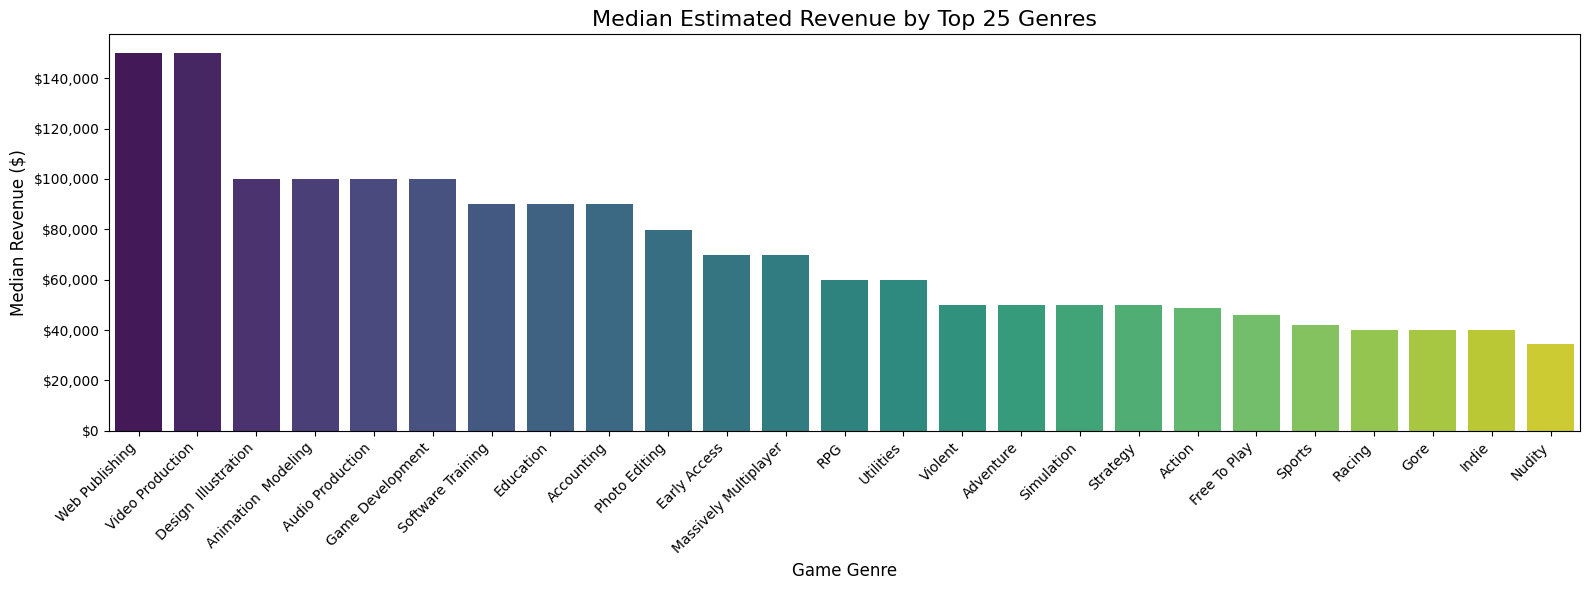

In [5]:
print("--- Encoding Genre Data ---")

# We use df_premium as our base for analysis
df_analysis = df_premium.copy()

# 1. Clean the genres column
def clean_genres(g):
    if pd.isna(g):
        return []
    
    # Remove non-alphanumeric characters except commas and spaces
    g = re.sub(r'[^a-zA-Z0-9, ]', '', str(g))
    
    # Split, strip, and capitalize the first letter of each genre 
    # without lowercasing the rest (e.g. keeps "Early Access" capitalized if it was)
    return [genre.strip()[:1].upper() + genre.strip()[1:] for genre in g.split(',') if genre.strip()]

df_analysis['genres_list'] = df_analysis['genres'].apply(clean_genres)

# 2. Initialize and fit MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df_analysis['genres_list'])

# 3. Create genre DataFrame and join it back
genre_df = pd.DataFrame(genre_matrix, columns=mlb.classes_, index=df_analysis.index)
df_analysis = df_analysis.join(genre_df)

# 4. Calculate metrics for all genres
print(f"Total Unique Genres Found: {len(mlb.classes_)}")
print("\nCalculating genre metrics...")

genre_revenue_data = []
for genre in mlb.classes_:
    genre_subset = df_analysis[df_analysis[genre] == 1]
    
    if len(genre_subset) > 0:
        genre_revenue_data.append({
            'Genre': genre,
            'Median Revenue ($)': genre_subset['est_revenue'].median(),
            'Median Price ($)': genre_subset['price'].median(),
            'Total Games': len(genre_subset)
        })

df_genre_metrics = pd.DataFrame(genre_revenue_data)

# Sort all genres by Median Revenue descending
df_genre_metrics = df_genre_metrics.sort_values(by='Median Revenue ($)', ascending=False).reset_index(drop=True)

# List all genres ordered by revenue
sorted_all_genres = df_genre_metrics['Genre'].tolist()
print(f"All Genres (Ordered by Median Revenue): {', '.join(sorted_all_genres)}")

# 5. Visualization
# To maintain readability on the x-axis, we can display up to the top 25 genres smoothly.
top_n_plot = min(25, len(df_genre_metrics))
df_plot_metrics = df_genre_metrics.head(top_n_plot)

plt.figure(figsize=(16, 6)) # Widened to fit more genres
ax = sns.barplot(
    data=df_plot_metrics, 
    x='Genre', 
    y='Median Revenue ($)', 
    hue='Genre',
    palette='viridis',
    legend=False
)

plt.title(f'Median Estimated Revenue by Top {top_n_plot} Genres', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

plt.tight_layout()
os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/median_revenue_by_genre.png')
plt.show()

### Genres and Professional Production Software
The list of genres presents a clear problem. Looking at the dataset, it is now clear that the dataset also includes titles that aren't games! In fact, the great majority of revenue is generated by this non-game software (which is interesting enough for an additional analysis all on its own). Additionally, there are titles that are labeled with the genre of *Early Access*. This is actually a stage of production, not a genre in and of itself. Therefore, it should be removed from the genre list. There are also games that are labeled as *Free To Play*, but aren't actually free. This is a case of misrepresentation or noise in the genre list. These genres should be removed. However this produces a problem. There may also be titles that have no genre, and titles that only have the genre *Early Access* or *Free To Play* or both, which would have no genre after these genres are removed. These titles should be relabeled as *No Genre*, but still be included in our analysis of all non-game titles. Therefore, our next task is thus:
1. Find out how many genres there are
2. Create a new column in our dataframe called *Game* that is a binary True/False
3. Create a new column in our dataframe called *Early Access* that is also a binary
4. Remove the *Early Access* and *Free To Play* genres from the genre list
5. Count these titles and tell us how many of each
6. Create a new genre called *No Genre* that is composed of games that have no genre after removing *Early Access* from the list of genres
7. Recreate the Median Revenue vs Game Genre graph using this new genre list while also excluding all non-games.

--- Investigating Early Access, Free To Play, Genres, & Non-Games ---
Total premium titles in dataset: 97,734
Titles that are Non-Games (Professional Software/Video): 1,265
Titles that had ONLY 'Early Access' originally: 27
Titles that had ONLY 'Free To Play' originally: 1
Titles that had NO genres at all originally: 109
Total titles successfully mapped to 'No Genre': 137

--- Recreating Median Revenue vs Genre Graph (Games Only) ---
Total Unique Game Genres Found (Including 'No Genre'): 15



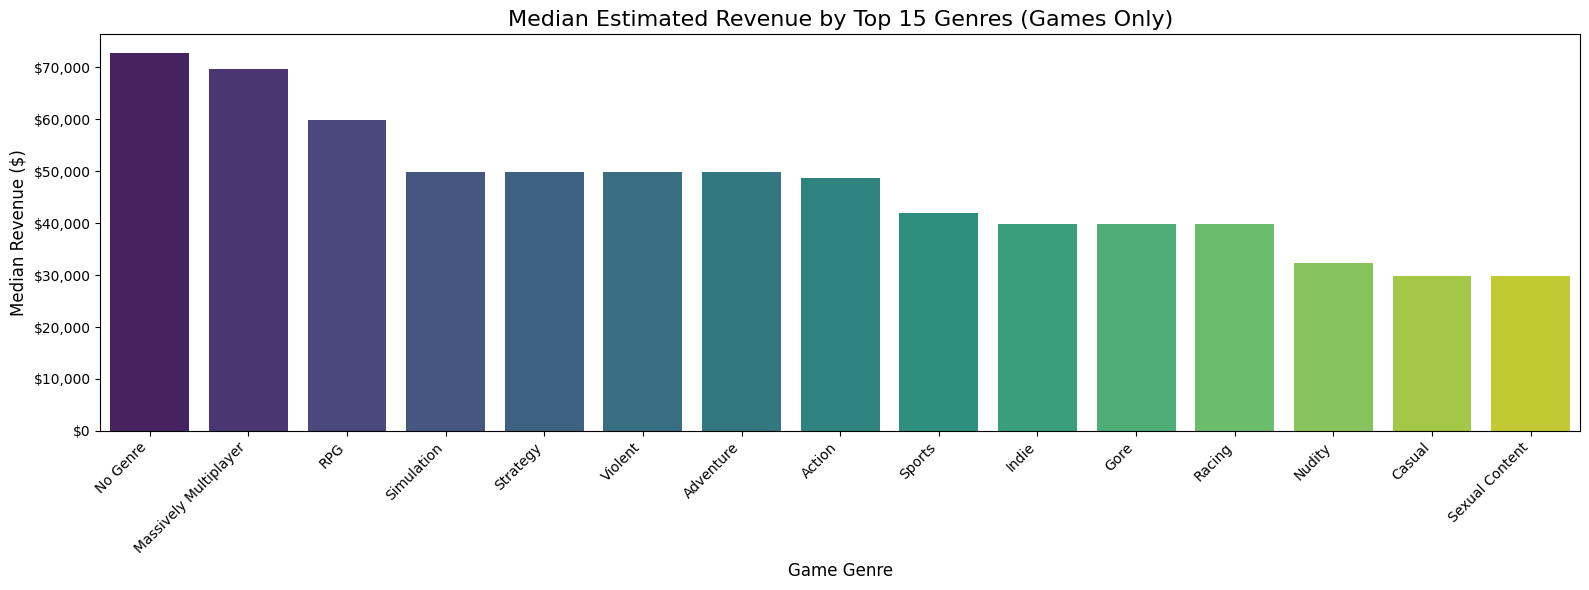

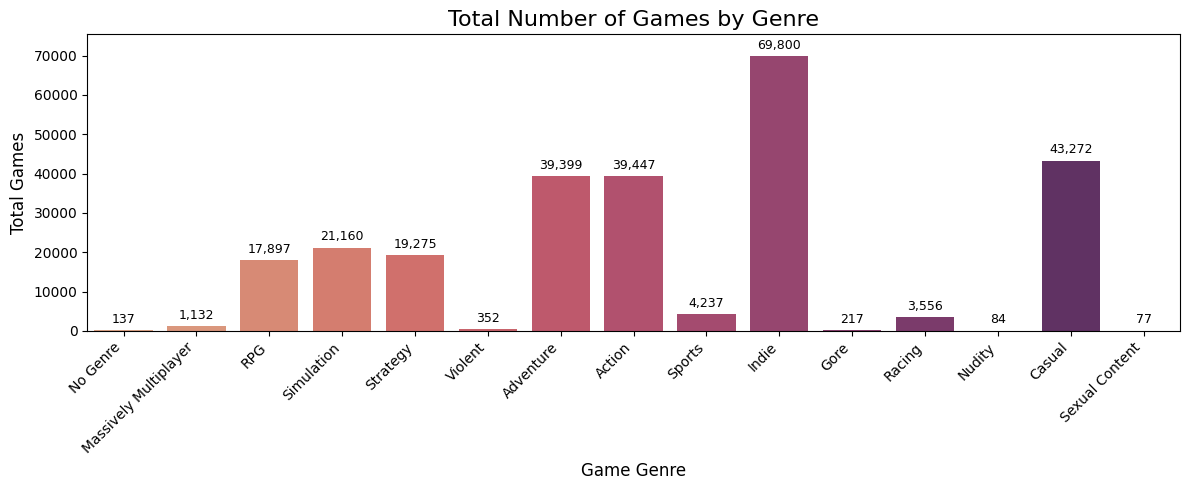

In [6]:
print("--- Investigating Early Access, Free To Play, Genres, & Non-Games ---")

# We use df_premium as our base since it contains all priced titles
df_analysis = df_premium.copy()

# 1. Define non-game genres (matching the alphanumeric cleaning format)
non_game_genres = set([
    'Web Publishing', 'Video Production', 'Design  Illustration', 'Animation  Modeling', 
    'Audio Production', 'Game Development', 'Software Training', 'Education', 
    'Accounting', 'Photo Editing', 'Utilities', '360 Video', 'Documentary', 
    'Episodic', 'Movie', 'Short', 'Tutorial'
])

# Clean the initial strings into python lists
def initial_clean(g):
    if pd.isna(g):
        return []
    # Remove non-alphanumeric characters except commas and spaces
    g = re.sub(r'[^a-zA-Z0-9, ]', '', str(g))
    return [genre.strip()[:1].upper() + genre.strip()[1:] for genre in g.split(',') if genre.strip()]

df_analysis['initial_genres'] = df_analysis['genres'].apply(initial_clean)

# 2. Create 'Game' binary column (True if it lacks non-game tags, False if it has them)
df_analysis['Game'] = df_analysis['initial_genres'].apply(lambda x: not any(g in non_game_genres for g in x))

# 3. Create 'Early_Access' and 'Free_To_Play' binary columns
df_analysis['Early_Access'] = df_analysis['initial_genres'].apply(lambda x: 'Early Access' in x)
df_analysis['Free_To_Play'] = df_analysis['initial_genres'].apply(lambda x: 'Free To Play' in x)

# --- Calculate Requested Metrics Before Modifying the Lists ---
only_ea_mask = df_analysis['initial_genres'].apply(lambda x: len(x) == 1 and 'Early Access' in x)
only_f2p_mask = df_analysis['initial_genres'].apply(lambda x: len(x) == 1 and 'Free To Play' in x)
no_genre_initial_mask = df_analysis['initial_genres'].apply(lambda x: len(x) == 0)

# 4. Clean the genre list: Remove non-game genres, 'Early Access', and 'Free To Play'
def finalize_genres(row):
    # Keep only standard genres
    filtered = [g for g in row['initial_genres'] if g not in non_game_genres and g not in ['Early Access', 'Free To Play']]
    
    # 6. If it's a Game and the resulting list is empty, label as "No Genre"
    if row['Game'] and len(filtered) == 0:
        return ['No Genre']
    
    return filtered

df_analysis['final_genres'] = df_analysis.apply(finalize_genres, axis=1)

# Count how many titles ended up in our new "No Genre" category
no_genre_final_mask = df_analysis['final_genres'].apply(lambda x: 'No Genre' in x)

# 5. Print the requested counts
print(f"Total premium titles in dataset: {len(df_analysis):,}")
print(f"Titles that are Non-Games (Professional Software/Video): {(~df_analysis['Game']).sum():,}")
print(f"Titles that had ONLY 'Early Access' originally: {only_ea_mask.sum():,}")
print(f"Titles that had ONLY 'Free To Play' originally: {only_f2p_mask.sum():,}")
print(f"Titles that had NO genres at all originally: {no_genre_initial_mask.sum():,}")
print(f"Total titles successfully mapped to 'No Genre': {no_genre_final_mask.sum():,}")

print("\n--- Recreating Median Revenue vs Genre Graph (Games Only) ---")

# 7. Filter to ONLY games for the graphing portion (dropping professional software)
df_games_only = df_analysis[df_analysis['Game'] == True].copy()

# Set the main dataframe to our cleaned games-only data for all future cells!
df = df_games_only.copy()

# Initialize MultiLabelBinarizer on our finalized list
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df_games_only['final_genres'])

print(f"Total Unique Game Genres Found (Including 'No Genre'): {len(mlb.classes_)}\n")

# Calculate metrics directly using the matrix for better memory efficiency
genre_revenue_data = []
for i, genre in enumerate(mlb.classes_):
    # Create a boolean mask for the current genre
    genre_mask = genre_matrix[:, i] == 1
    genre_subset = df_games_only[genre_mask]
    
    if len(genre_subset) > 0:
        genre_revenue_data.append({
            'Genre': genre,
            'Median Revenue ($)': genre_subset['est_revenue'].median(),
            'Median Price ($)': genre_subset['price'].median(),
            'Total Games': len(genre_subset)
        })

df_genre_metrics = pd.DataFrame(genre_revenue_data)

# Sort all genres by Median Revenue descending
df_genre_metrics = df_genre_metrics.sort_values(by='Median Revenue ($)', ascending=False).reset_index(drop=True)

# Visualization
top_n_plot = min(25, len(df_genre_metrics))
df_plot_metrics = df_genre_metrics.head(top_n_plot)

plt.figure(figsize=(16, 6)) 
ax = sns.barplot(
    data=df_plot_metrics, 
    x='Genre', 
    y='Median Revenue ($)', 
    hue='Genre',
    palette='viridis',
    legend=False
)

plt.title(f'Median Estimated Revenue by Top {top_n_plot} Genres (Games Only)', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

plt.tight_layout()
os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/median_revenue_by_genre_games_only.png')
plt.show()

# 8. Count the number of games per genre and create a histogram for the distribution of game counts across genres
# Ensure the genres are in order of revenue for the histogram as well
plt.figure(figsize=(12, 5))
sns.barplot(
    data=df_genre_metrics, 
    x='Genre', 
    y='Total Games', 
    hue='Genre',
    palette='flare',
    legend=False
)
plt.title('Total Number of Games by Genre', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Total Games', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
max_count = df_genre_metrics['Total Games'].max()

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{int(h):,}",
            (p.get_x() + p.get_width() / 2, h),
            ha='center',
            va='bottom',
            fontsize=9,
            xytext=(0, 3),
            textcoords='offset points'
        )

ax.set_ylim(0, max_count * 1.08)
plt.tight_layout()
plt.savefig('graphs/total_games_by_genre.png')
plt.show()

## Data Refinement & Genre Analysis

To accurately identify the pricing "sweet spot," we first isolated video games from professional software and utility applications to ensure the data reflects actual gaming market trends.

### Preprocessing Results
The refinement of the **97,734** premium titles in the dataset provided a much clearer picture of the marketplace:
* **Non-Game Titles Removed**: **1,265** titles (such as accounting software and video production tools) were flagged and separated from the game analysis.
* **"No Genre" Consolidation**: A total of **137** titles were successfully mapped to the "No Genre" category. This group includes **109** games that originally had no genre tags and **27** games that were only labeled as "Early Access and **1** game that was only labeled as "Free To Play".

---

### Median Revenue Insights (Games Only)
The chart displays the median estimated revenue for the **15 unique game genres** remaining after our cleanup.

* **The "No Genre" Premium**: Paradoxically, games without a standard genre tag lead the dataset with a median revenue exceeding **$70,000**. This suggests that titles which defy traditional categorization (often niche or highly specialized experiences) may command higher price points or achieve more concentrated financial success.
* **High-Investment Genres**: **Massively Multiplayer** and **RPG** titles follow closely, with median revenues near **$70,000** and **$60,000** respectively. These genres typically require significant player time investment, which often correlates with higher initial pricing.
* **Volume-Driven Markets**: At the lower end of the scale, genres such as **Casual**, **Sexual Content**, and **Nudity** show median revenues between **$30,000 and $35,000**. The pricing "sweet spot" for these titles is likely lower, reflecting a high-volume, lower-price competitive landscape.

By reclassifying "Early Access" and removing professional software, we can now base our pricing model on a clean dataset where the results are driven by game mechanics rather than enterprise software costs.

### Aside: Understanding the "Clean" Revenue Values

While real-world financial data is usually messy, the strikingly "neat" numbers in this analysis, such as **$70,000**, **$60,000**, and **$50,000**, are a direct result of how the dataset's raw inputs are structured.

* **The Owner Midpoint Effect**: Steam ownership data is typically provided in discrete ranges (e.g., 20,000–50,000) rather than exact figures. In Task 3 of our preprocessing, we converted these ranges into a single **midpoint value** (e.g., 35,000) for calculation.
* **Mathematical "Steps"**: When we multiply a fixed midpoint by a standardized price, we create thousands of identical revenue figures across the dataset. For example, 35,000 owners multiplied by a $2.00 price point results in exactly **$70,000**.
* **The Nature of the Median**: Because so many games share these identical calculated revenues, the **median** (the middle value of the sorted list) almost always lands on one of these common "steps" rather than a precise, fractional dollar amount. 

In short: the numbers aren't "clean" because the market is simple, but because we are looking at the **mathematical middle point** of standardized data brackets.

## Concurrent Players
Revenue isn't everything. Oftentimes, a title that generates lots of revenue does so by utilizing anti-consumer practices that turn players away from future releases from the same publisher or developer. High values of **concurrent players** also contribute to determining a game's "value" and should also be utilized to determine pricing. Of course, since players must pay the price first in order to play the game, this is a "retroactive" feature. That is, the concurrent player number may be a result of the pricing, not the other way around.<br><br>
Regardless, plotting the concurrent players vs the game genre can provide some insight into how many people play games of a certain genre long-term. Let's do that now.

--- Calculating Peak CCU by Genre ---

Saved plot to 'graphs/median_ccu_by_genre.png'


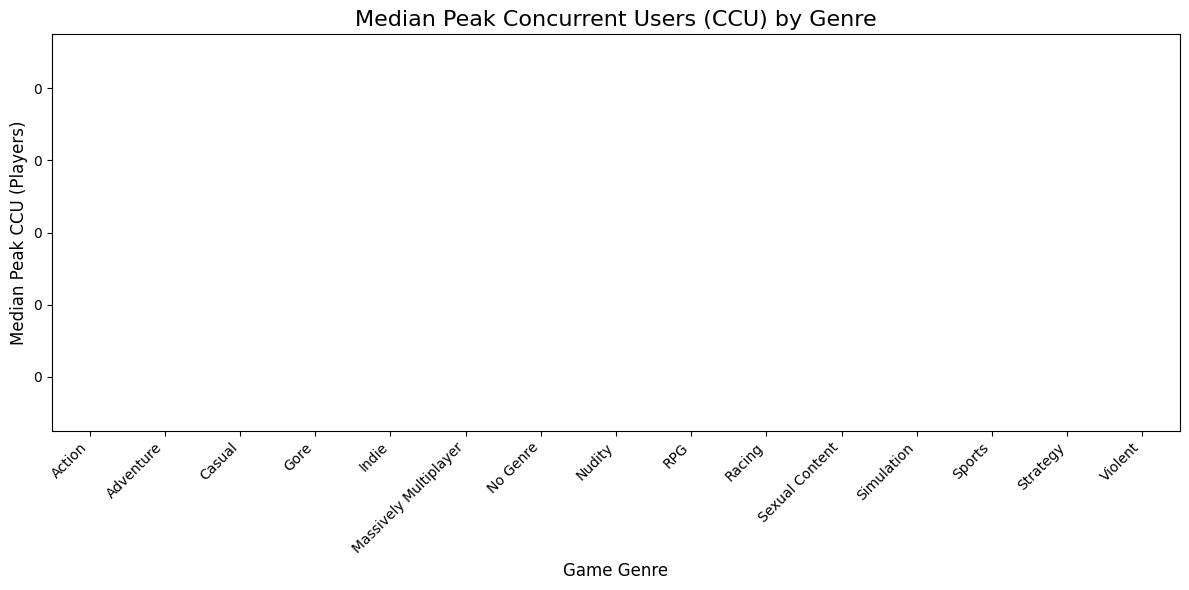

In [7]:
print("--- Calculating Peak CCU by Genre ---")

# Explode the genres list so each game has one row per genre it belongs to
df_exploded = df.explode('final_genres')

# Calculate the median Peak CCU for each genre
df_ccu_metrics = df_exploded.groupby('final_genres')['peak_ccu'].median().reset_index()
df_ccu_metrics.columns = ['Genre', 'Median Peak CCU']

# Sort by CCU for a better visual flow
df_ccu_metrics = df_ccu_metrics.sort_values(by='Median Peak CCU', ascending=False)

# Visualization
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_ccu_metrics, 
    x='Genre', 
    y='Median Peak CCU', 
    hue='Genre',
    palette='magma', 
    legend=False
)

plt.title('Median Peak Concurrent Users (CCU) by Genre', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Peak CCU (Players)', fontsize=12)
plt.xticks(rotation=45, ha='right')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()

os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/median_ccu_by_genre.png')
print("\nSaved plot to 'graphs/median_ccu_by_genre.png'")

plt.show()

### The "Dead Game" Phenomenon (Fixing the Blank Graph)
Looking at the graph above, it appears entirely blank. Did the code fail? Actually, it didn't! The code executed perfectly, but it revealed a harsh reality of the Steam marketplace: **The overwhelming majority of games on Steam are "dead."**

Because Steam has very low barriers to entry, the store is flooded with abandoned student projects, asset flips (titles that leave default placeholder engine assets in place of created assets), and forgotten indie titles that have a Peak Concurrent User (CCU) count of exactly **0**. Because we used the **Median** to calculate our metric, these tens of thousands of dead games dragged the mathematical middle point for every single genre down to literal zero.

To get an accurate picture of the market, we need to filter our dataset to only include **Active Games**, titles that successfully attracted at least 1 concurrent player. As such, let's remove these titles from consideration entirely and redraw the market matrix.

--- Recalculating Peak CCU (Active Games Only) ---
Dropped 79,340 'dead' games with 0 peak concurrent players.
Games with >0 CCU remaining for analysis: 17,129
Percentage of games that are 'inactive': 82.24%

Saved corrected plot to 'graphs/median_ccu_by_genre_active.png'


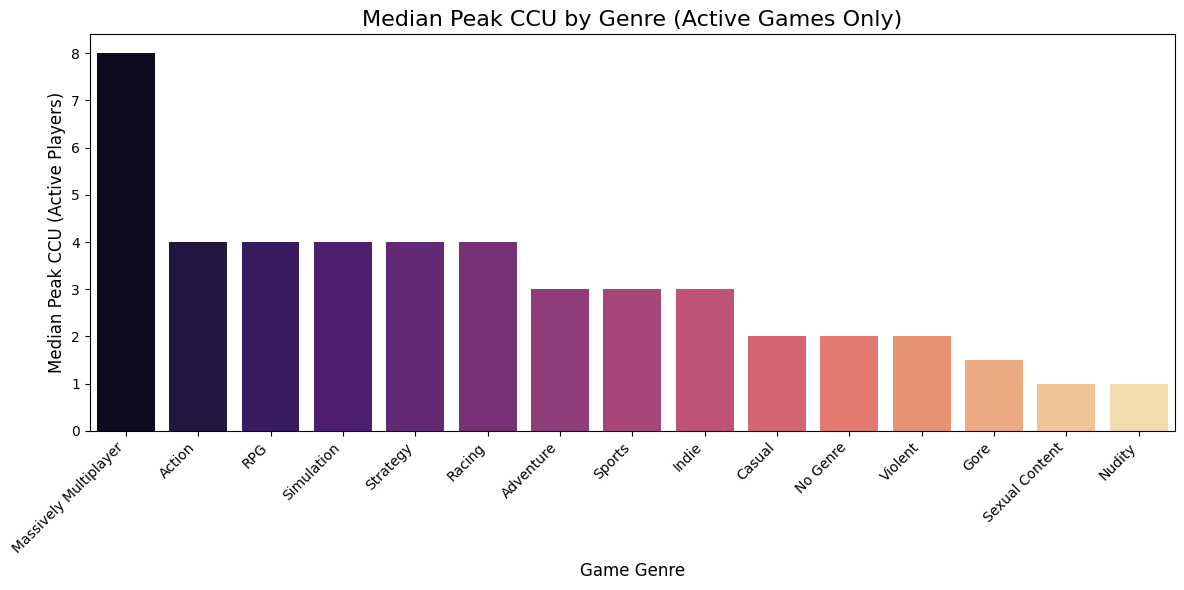

In [8]:
print("--- Recalculating Peak CCU (Active Games Only) ---")

# 1. Filter out the "dead" games that drag the median to 0
df_active_games = df[df['peak_ccu'] > 0].copy()

dead_games_dropped = len(df) - len(df_active_games)
print(f"Dropped {dead_games_dropped:,} 'dead' games with 0 peak concurrent players.")
print(f"Games with >0 CCU remaining for analysis: {len(df_active_games):,}")
print(f"Percentage of games that are 'inactive': {dead_games_dropped / len(df) * 100:.2f}%")

# 2. Recalculate using explode on the active games dataset
df_active_exploded = df_active_games.explode('final_genres')
df_ccu_active = df_active_exploded.groupby('final_genres')['peak_ccu'].median().reset_index()
df_ccu_active.columns = ['Genre', 'Median Peak CCU']
df_ccu_active = df_ccu_active.sort_values(by='Median Peak CCU', ascending=False)

# 3. Render the Corrected Chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_ccu_active, 
    x='Genre', 
    y='Median Peak CCU', 
    hue='Genre',
    palette='magma', 
    legend=False
)

plt.title('Median Peak CCU by Genre (Active Games Only)', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Peak CCU (Active Players)', fontsize=12)
plt.xticks(rotation=45, ha='right')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()

plt.savefig('graphs/median_ccu_by_genre_active.png')
print("\nSaved corrected plot to 'graphs/median_ccu_by_genre_active.png'")
plt.show()

To little surprise, the *Massively Multiplayer* genre also has a large median concurrent player base. As the previous cell showed, a whopping 79,340 titles had *no concurrent players*! This composed 82.24% of all titles! Because of this large change in the dataset, let's recreate Revenue vs Genre graph so that we can see if anything's changed after dropping all the abandonware.

--- Recreating Cleaned Revenue Graph: ACTIVE GAMES ONLY ---
Original dataset (100% of games) saved to 'originalDF'. Size: 96,469
Active games dataset set to main 'df'. Size: 17,129

Saved plot to 'graphs/median_revenue_by_genre_cleaned_active.png'


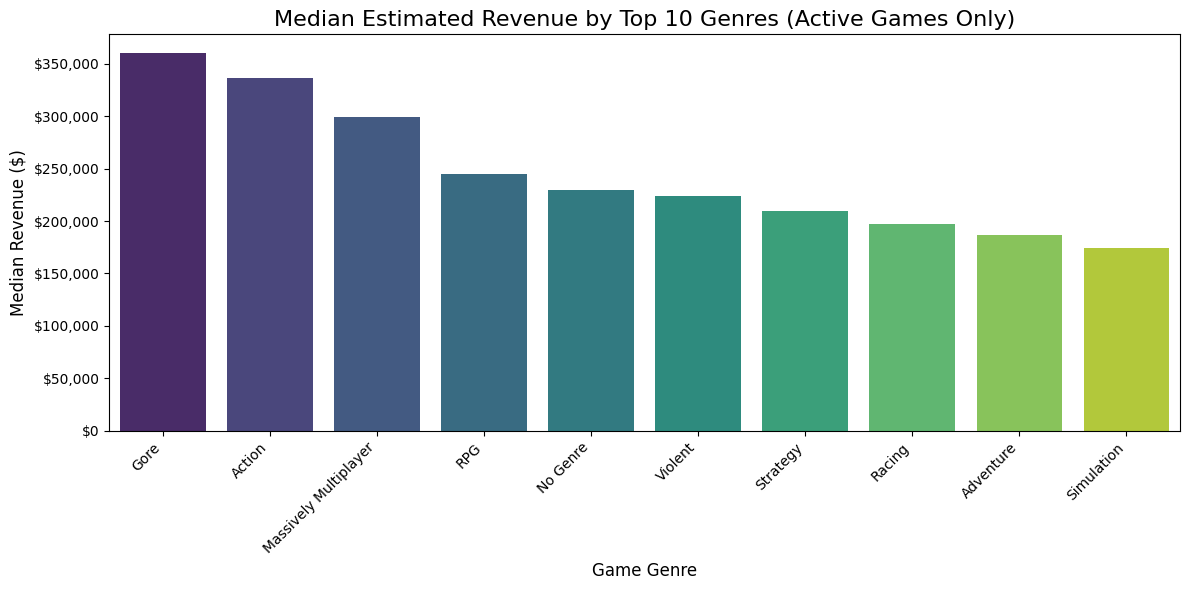

In [9]:
print("--- Recreating Cleaned Revenue Graph: ACTIVE GAMES ONLY ---")
os.makedirs('graphs', exist_ok=True)

# 1. State Management: Save the original and update the main 'df'
# We use our previously cleaned 'df' as the original because it contains the 100% complete dataset 
# with the 'No Genre' categorization successfully applied.
originalDF = df.copy() 
df = df_active_games.copy()

print(f"Original dataset (100% of games) saved to 'originalDF'. Size: {len(originalDF):,}")
print(f"Active games dataset set to main 'df'. Size: {len(df):,}")

# 2. Recalculate the Median Revenue metrics using the new main 'df'
# Explode the genres list so we can aggregate them easily
df_exploded_active = df.explode('final_genres')

# Group by genre and calculate median revenue
df_rev_active = df_exploded_active.groupby('final_genres')['est_revenue'].median().reset_index()
df_rev_active.columns = ['Genre', 'Median Revenue ($)']

# Sort descending to find the top performing genres
df_rev_active = df_rev_active.sort_values(by='Median Revenue ($)', ascending=False)

# Take the top 10 for the graph to match the title
df_rev_plot = df_rev_active.head(10)

# 3. Render the Chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_rev_plot, 
    x='Genre', 
    y='Median Revenue ($)', 
    hue='Genre', 
    palette='viridis', 
    legend=False
)

plt.title('Median Estimated Revenue by Top 10 Genres (Active Games Only)', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Format Y-axis to add dollars and commas cleanly
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))
plt.tight_layout()

# 4. Save with a distinct filename
plt.savefig('graphs/median_revenue_by_genre_cleaned_active.png')
print("\nSaved plot to 'graphs/median_revenue_by_genre_cleaned_active.png'")

plt.show()

## Total Playtime
Financial success (Revenue) and viral engagement (Peak CCU) are crucial, but they don't tell the whole story. To truly understand the value proposition of a genre, we must look at **Player Retention**, measured by Median Playtime. 

Does a high price tag guarantee a long, engaging experience? Do certain genres command massive loyalty and hundreds of hours of gameplay? By analyzing the median playtime of our active market (games with >0 concurrent players), we can see which genres keep players coming back for more. 

*Note: Steam typically tracks playtime in minutes, so we will convert this data into hours for a clearer business visualization.*

--- Calculating Playtime & Revenue by Genre (Active Games) ---

Saved plot to 'graphs/median_playtime_by_genre.png'


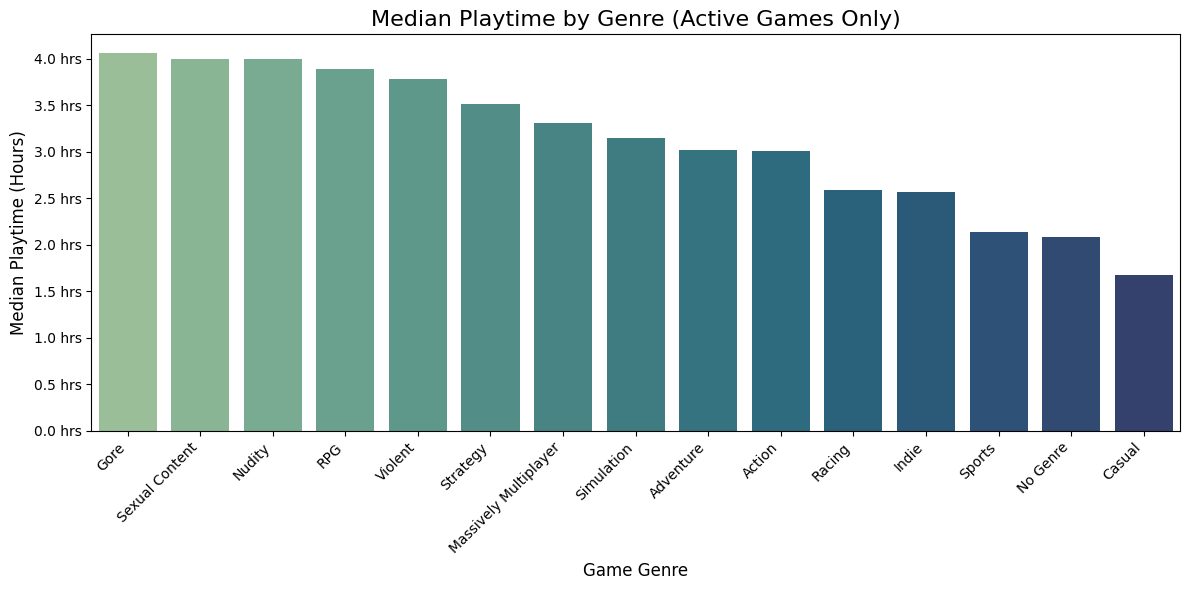

In [10]:
print("--- Calculating Playtime & Revenue by Genre (Active Games) ---")

# Use our exploded active games dataframe to get Playtime
playtime_col = 'median_playtime_forever' if 'median_playtime_forever' in df.columns else 'average_playtime_forever'
df_active_exploded['Playtime (Hours)'] = df_active_exploded[playtime_col] / 60.0

df_playtime_metrics = df_active_exploded.groupby('final_genres')['Playtime (Hours)'].median().reset_index()
df_playtime_metrics.columns = ['Genre', 'Median Playtime (Hours)']
df_playtime_metrics = df_playtime_metrics.sort_values(by='Median Playtime (Hours)', ascending=False)

# Render Playtime Chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_playtime_metrics, 
    x='Genre', 
    y='Median Playtime (Hours)', 
    hue='Genre',
    palette='crest', 
    legend=False
)
27
plt.title('Median Playtime by Genre (Active Games Only)', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Playtime (Hours)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.1f} hrs".format(x)))
plt.tight_layout()

plt.savefig('graphs/median_playtime_by_genre.png')
print("\nSaved plot to 'graphs/median_playtime_by_genre.png'")
plt.show()

# Pricing Optimization
All that we have done so far is **Descripting Analytics**. Let's move on to Pricing Optimization. This is an example of **Prescriptive Analytics**, and is valuable business intelligence that can improve sales figures for any hypothetical publishing companies that would like to release titles in the near future.

## The Plan
We cannot simply predict "Price" as our target variable, because the dataset is full of games that were priced poorly and made no money! If we train a model to predict the price, it will just learn to predict average prices, not optimal prices.

Instead, we will:

1. **Target Variable**: Train a model to predict Estimated Revenue.
2. **Features**: Feed the model the Price, Early Access status, and the Genres.
3. **The Simulation**: Once the model is trained, we will create a "hypothetical" game for a specific genre (e.g., an Action game). We will ask the model to predict the revenue for this game at $1, $2, $3... all the way to $100.
4. **The Sweet Spot**: We will plot these predictions. The price point where the model predicts the highest revenue is our mathematical "Sweet Spot."

## Pricing Optimization Models
We will clean the dataframe a bit first. This involves

In [11]:
print("--- Preparing Data for Machine Learning ---")

# 1. Isolate the features and RESET INDEX
# We use .reset_index(drop=True) to turn those jumping numbers back into a clean 0, 1, 2... sequence
df_model = df_active_games[['price', 'est_revenue', 'Early_Access', 'final_genres']].copy().reset_index(drop=True)

# 2. One-Hot Encode the genres using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genre_features = mlb.fit_transform(df_model['final_genres'])
genre_columns = [f"Genre_{g}" for g in mlb.classes_]

# 3. Merge the binary genre columns back into our modeling dataframe
df_genres = pd.DataFrame(genre_features, columns=genre_columns) # No index needed here as it's now aligned
df_model = pd.concat([df_model.drop(columns=['final_genres']), df_genres], axis=1)

# Ensure Early_Access is an integer (1 or 0)
df_model['Early_Access'] = df_model['Early_Access'].astype(int)

print(f"Modeling dataset created!\nTotal columns: {len(df_model.columns)}")
# Display the feature list and the first few rows to confirm
display(df_model.head())
# Show model feature list (exclude target)
feature_cols = [col for col in df_model.columns if col != 'est_revenue']

print("\n--- Feature List ---")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:02d}. {col}")

print(f"\nTotal Features: {len(feature_cols)}")
print("Target Column: est_revenue")

--- Preparing Data for Machine Learning ---
Modeling dataset created!
Total columns: 18


,price,est_revenue,Early_Access,Genre_Action,Genre_Adventure,Genre_Casual,Genre_Gore,Genre_Indie,Genre_Massively Multiplayer,Genre_No Genre,Genre_Nudity,Genre_RPG,Genre_Racing,Genre_Sexual Content,Genre_Simulation,Genre_Sports,Genre_Strategy,Genre_Violent
0,8.99,89900.0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0
1,35.99,359900.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
2,0.59,5900.0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0
3,13.99,2098500.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,5.99,59900.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0



--- Feature List ---
01. price
02. Early_Access
03. Genre_Action
04. Genre_Adventure
05. Genre_Casual
06. Genre_Gore
07. Genre_Indie
08. Genre_Massively Multiplayer
09. Genre_No Genre
10. Genre_Nudity
11. Genre_RPG
12. Genre_Racing
13. Genre_Sexual Content
14. Genre_Simulation
15. Genre_Sports
16. Genre_Strategy
17. Genre_Violent

Total Features: 17
Target Column: est_revenue


In [12]:
print("--- Training the Pricing Optimization Model ---")
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# 1. Define our Features (X) and Target (y)
X = df_model.drop(columns=['est_revenue'])
y = df_model['est_revenue']

# 2. Split into Training (80%) and Testing (20%) datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Random Forest
# We use 100 'trees' to ensure a stable prediction
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. Evaluate the Model
predictions = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print("Model successfully trained!")
print(f"Mean Absolute Error: ${mae:,.2f}")

--- Training the Pricing Optimization Model ---
Model successfully trained!
Mean Absolute Error: $7,258,877.95


--- Simulating the Pricing Sweet Spot for ALL Genres ---
Running simulation for 15 unique genres...

Simulation Complete! Plot saved with high-res aesthetics to 'graphs/pricing_sweet_spot_all_genres.png'


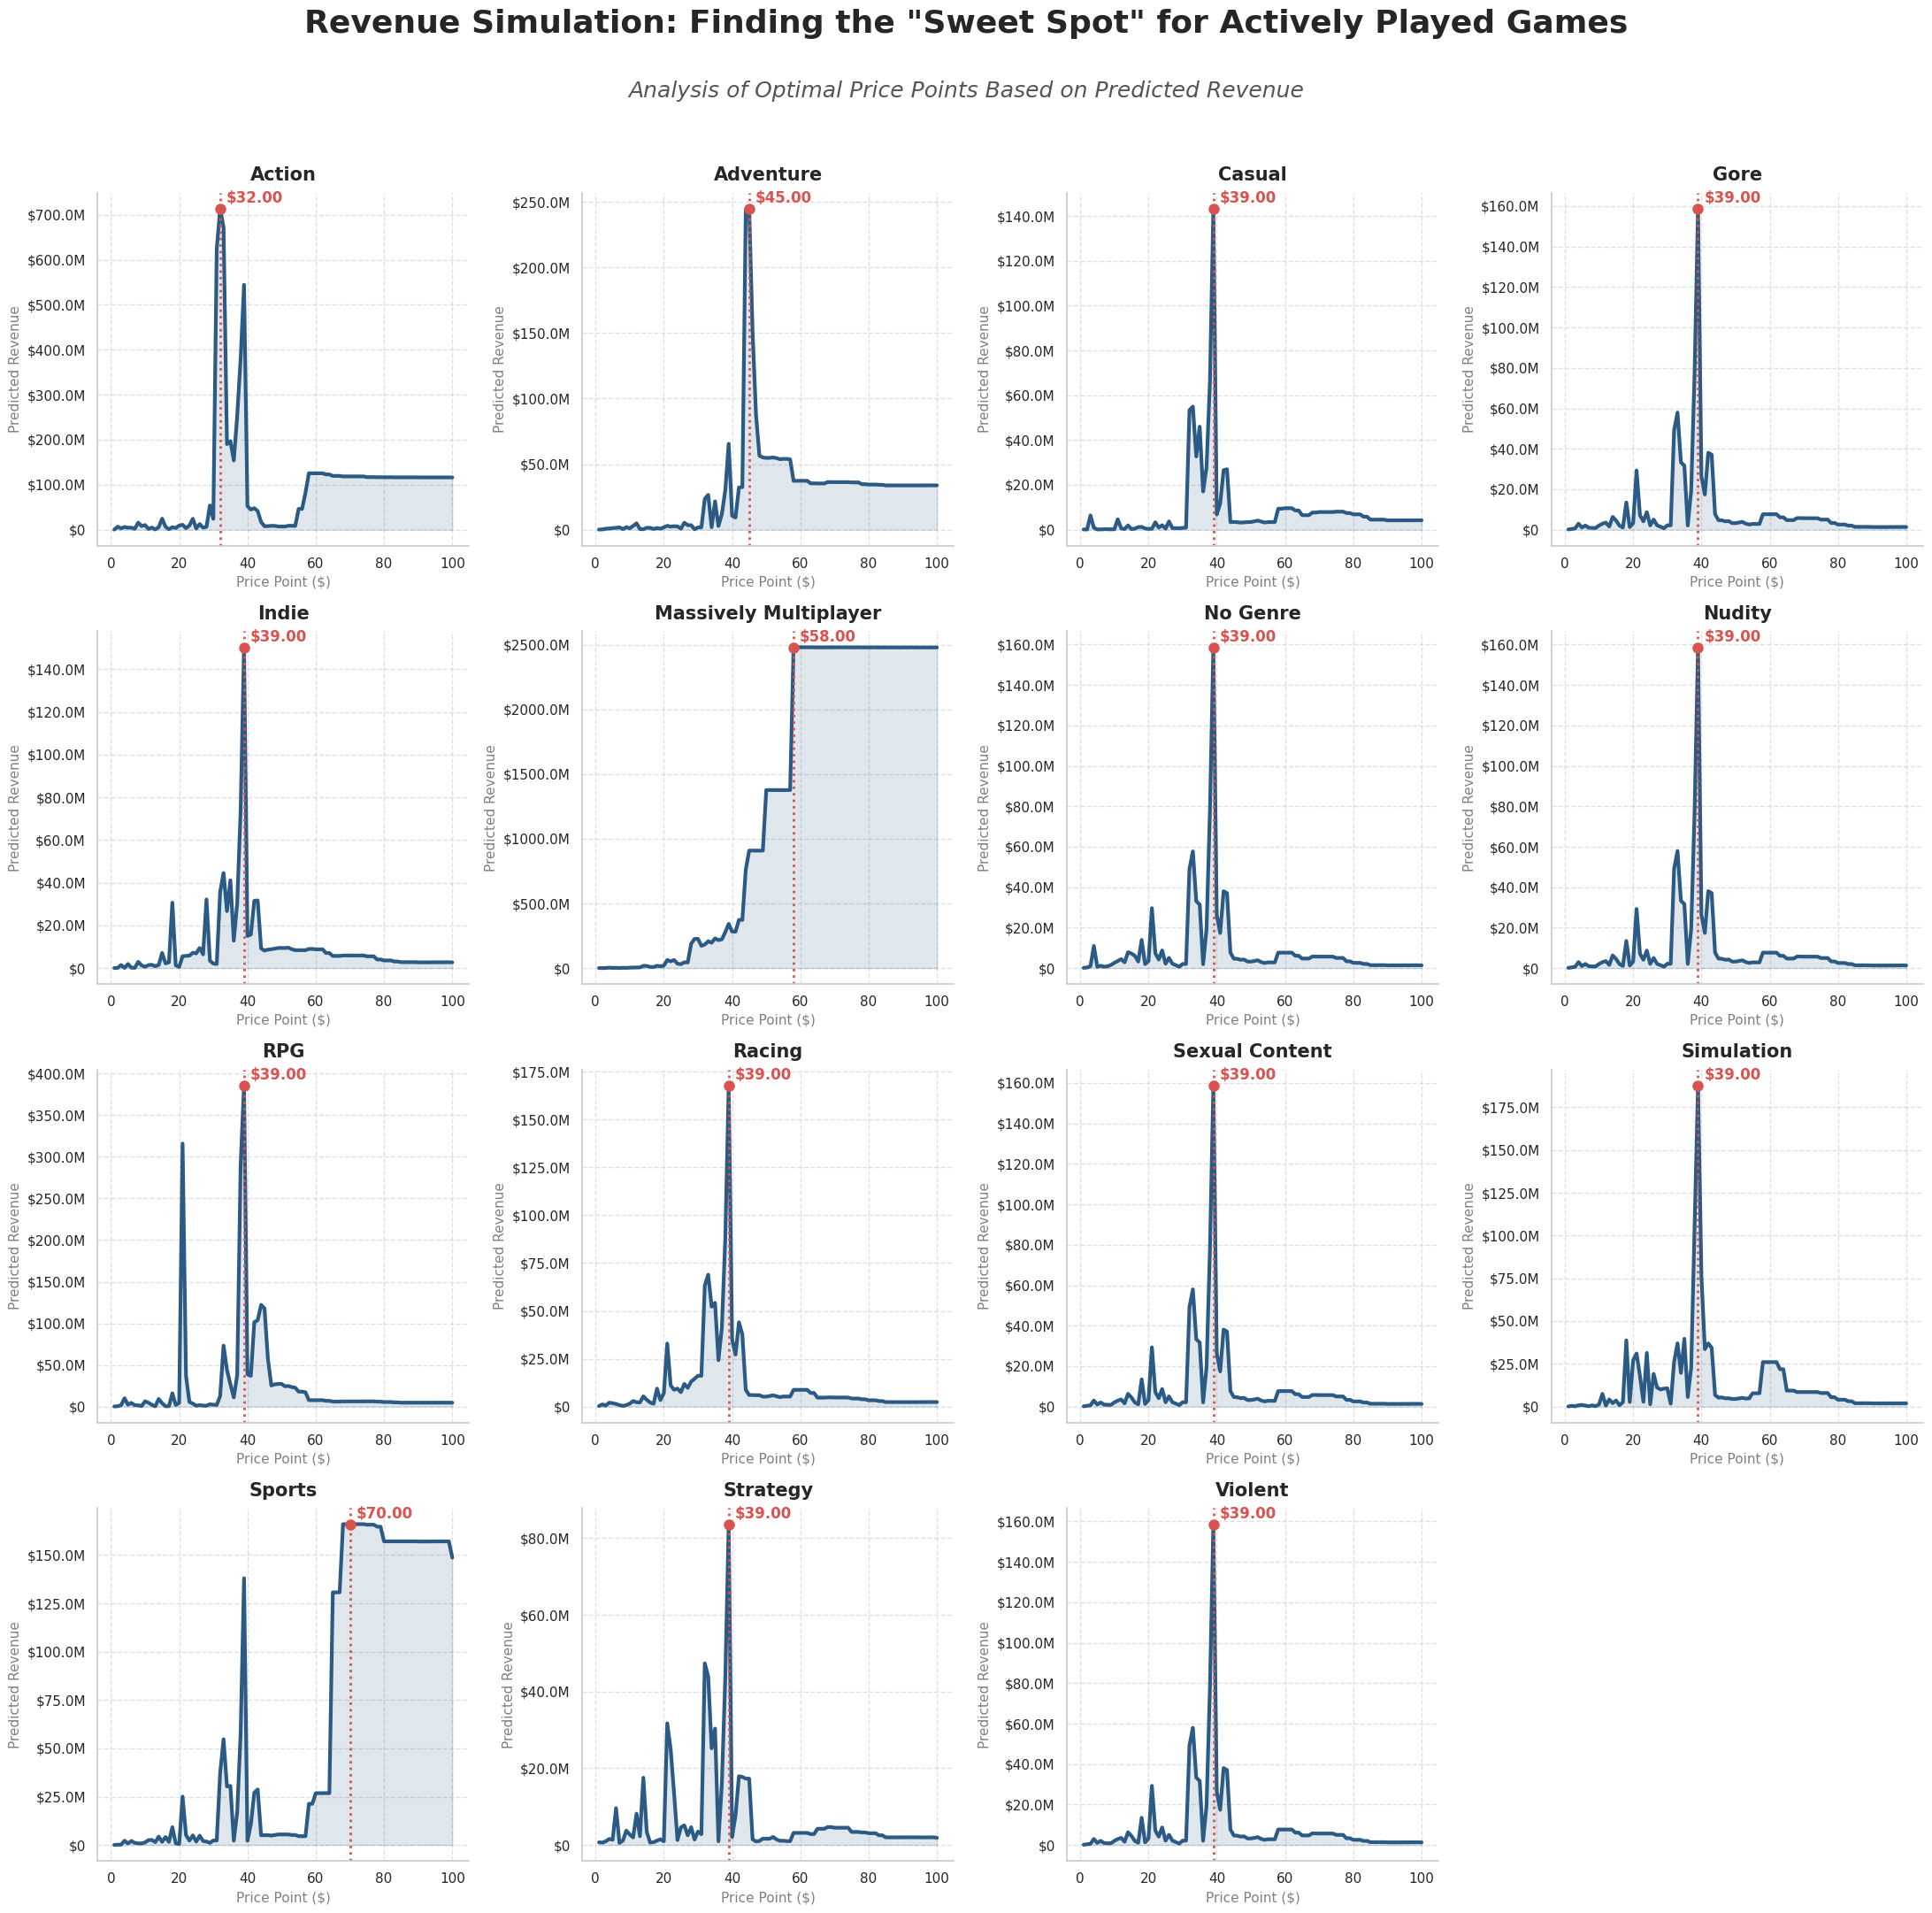

In [13]:
print("--- Simulating the Pricing Sweet Spot for ALL Genres ---")

# Set overall aesthetic style for a cleaner look
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

# 1. Identify all the genre columns
genre_cols = [col for col in X.columns if col.startswith('Genre_')]
num_genres = len(genre_cols)

# 2. Set up the grid
cols = 4
rows = (num_genres + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(22, 5 * rows))
axes = axes.flatten()

sim_prices = np.arange(1, 101, 1)

# Formatter for Millions and Thousands
def format_currency(x, pos):
    if x >= 1_000_000:
        return f'${x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'${x/1_000:.0f}K'
    return f'${x:.0f}'

print(f"Running simulation for {num_genres} unique genres...")

# 3. Loop through genres and simulate
for i, target_genre in enumerate(genre_cols):
    ax = axes[i]
    
    # Create simulation data
    sim_data = pd.DataFrame(0, index=np.arange(len(sim_prices)), columns=X.columns)
    sim_data['price'] = sim_prices
    sim_data['Early_Access'] = 0  
    sim_data[target_genre] = 1    
    
    # Predict Revenue
    sim_data['Predicted_Revenue'] = rf_model.predict(sim_data)
    
    # Find Sweet Spot
    optimal_idx = sim_data['Predicted_Revenue'].idxmax()
    optimal_price = sim_data.loc[optimal_idx, 'price']
    max_rev = sim_data.loc[optimal_idx, 'Predicted_Revenue']
    
    # Plotting the curve and area under curve
    ax.plot(sim_data['price'], sim_data['Predicted_Revenue'], color='#2b5b84', linewidth=3)
    ax.fill_between(sim_data['price'], sim_data['Predicted_Revenue'], color='#2b5b84', alpha=0.15)
    
    # Plotting the sweet spot marker and line
    ax.axvline(optimal_price, color='#d9534f', linestyle=':', linewidth=2)
    ax.plot(optimal_price, max_rev, marker='o', markersize=8, color='#d9534f')
    
    # Annotate sweet spot cleanly instead of using a legend
    ax.annotate(f'${optimal_price:.2f}', xy=(optimal_price, max_rev), 
                xytext=(5, 5), textcoords='offset points', 
                color='#d9534f', fontweight='bold', fontsize=12)
    
    # Labeling
    clean_name = target_genre.replace('Genre_', '')
    ax.set_title(clean_name, fontsize=15, fontweight='bold', pad=10)
    ax.set_xlabel('Price Point ($)', fontsize=11, color='gray')
    ax.set_ylabel('Predicted Revenue', fontsize=11, color='gray')
    ax.grid(True, alpha=0.6, linestyle='--')
    
    # Apply the currency formatter
    ax.yaxis.set_major_formatter(FuncFormatter(format_currency))

# 4. Cleanup empty subplots
for j in range(num_genres, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

# --- TITLE & SUBTITLE SECTION (INCREASED SPACING) ---
fig.suptitle('Revenue Simulation: Finding the "Sweet Spot" for Actively Played Games', 
             fontsize=26, fontweight='bold', y=1.08)
fig.text(0.5, 1.03, 'Analysis of Optimal Price Points Based on Predicted Revenue', 
         ha='center', fontsize=18, style='italic', color='#555555')

# 5. Save and display
os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/pricing_sweet_spot_all_genres.png', bbox_inches='tight', dpi=300)
print("\nSimulation Complete! Plot saved with high-res aesthetics to 'graphs/pricing_sweet_spot_all_genres.png'")

plt.show()

## Optimizing Price for Player Acquisition (CCU)

While maximizing immediate revenue is critical for financial success, long-term studio growth often relies on building a loyal, active player base. High Concurrent Users (CCU) signal a thriving community, which drives organic word-of-mouth marketing, higher visibility on the Steam store, and brand loyalty for future releases. 

To explore this alternative strategy, we will train a **second Random Forest Regressor**. This time, the model will attempt to predict `peak_ccu` instead of `est_revenue`. By running our $1 to $100 simulation through this new model, we can find the specific price points that reduce the barrier to entry just enough to maximize total player count without entirely devaluing the product.

--- Training the CCU Optimization Model ---
CCU Model successfully trained! Mean Absolute Error: 363.1 players

--- Simulating the CCU Sweet Spot for ALL Genres ---

Simulation Complete! Plot saved to 'graphs/pricing_sweet_spot_ccu_all_genres.png'


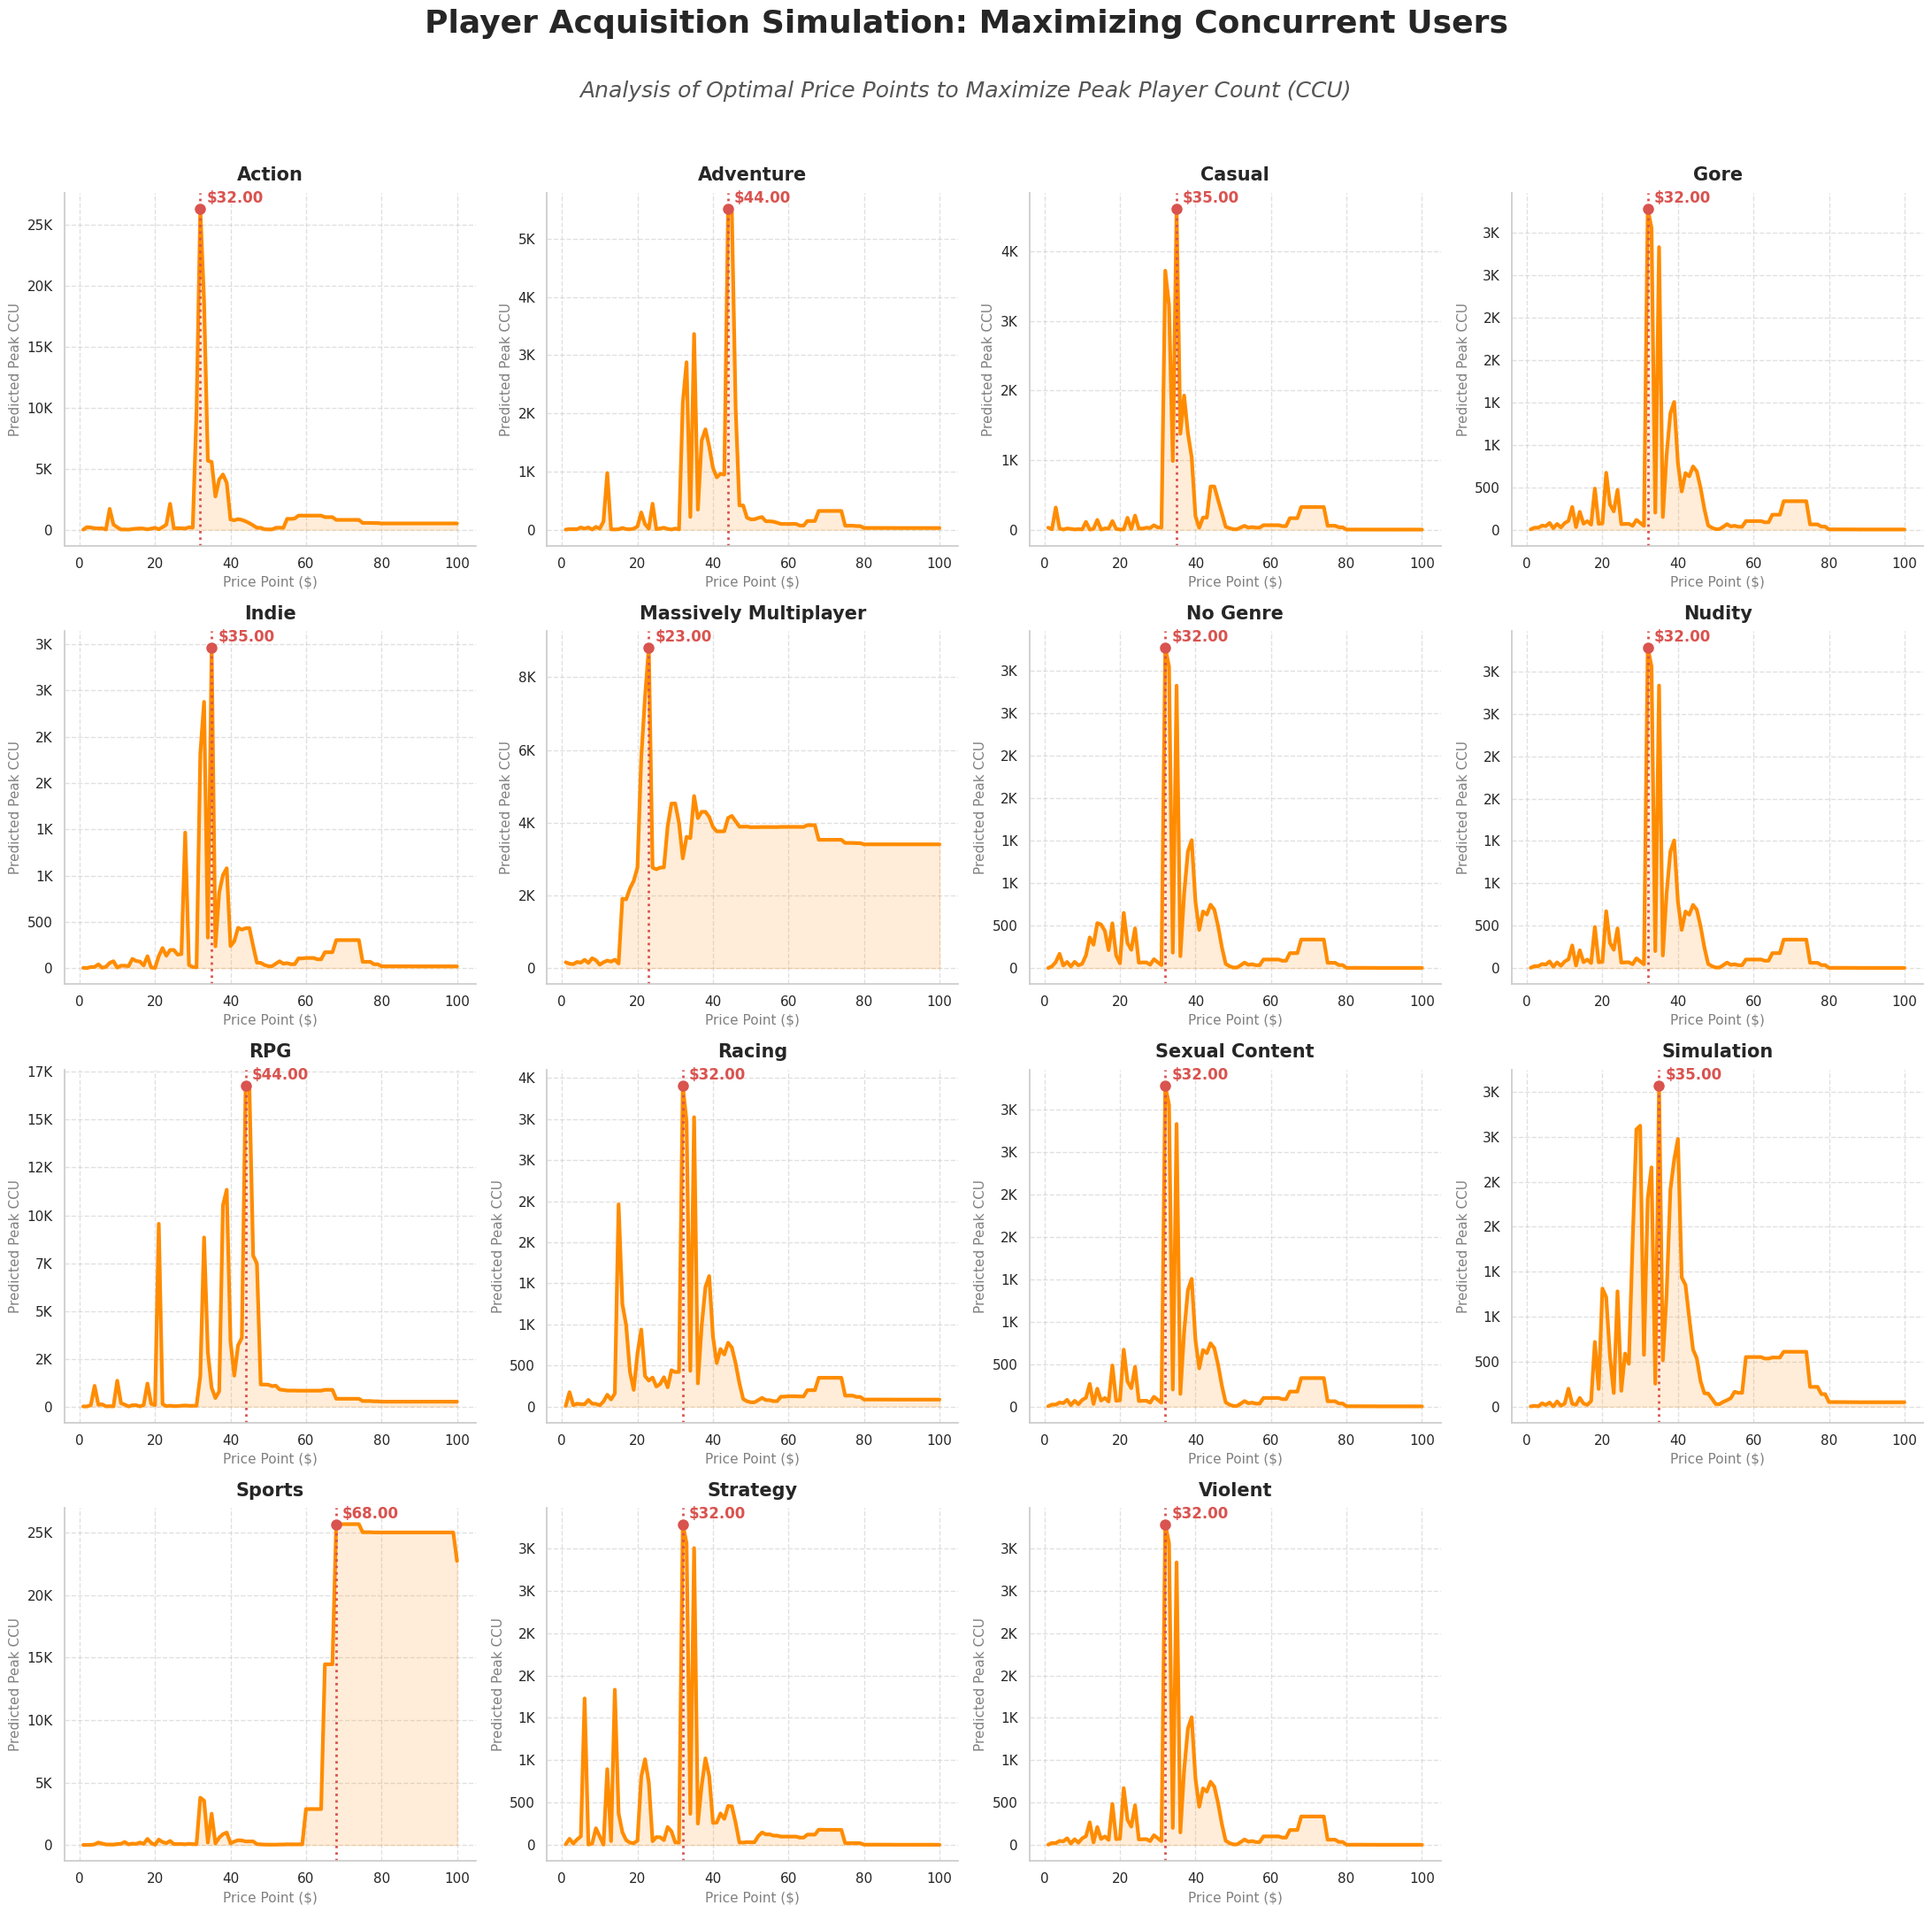

In [14]:
print("--- Training the CCU Optimization Model ---")

# 1. Define our new Target (y_ccu). We can reuse our existing Feature Matrix (X)!
# We use reset_index to ensure it perfectly aligns with X
y_ccu = df_active_games['peak_ccu'].copy().reset_index(drop=True)

# 2. Split into Training and Testing datasets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_ccu, test_size=0.2, random_state=42)

# 3. Initialize and Train the CCU Random Forest
rf_model_ccu = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_ccu.fit(X_train_c, y_train_c)

# Evaluate the Model
preds_c = rf_model_ccu.predict(X_test_c)
mae_c = mean_absolute_error(y_test_c, preds_c)
print(f"CCU Model successfully trained! Mean Absolute Error: {mae_c:,.1f} players")

print("\n--- Simulating the CCU Sweet Spot for ALL Genres ---")

# Setup the grid
genre_cols = [col for col in X.columns if col.startswith('Genre_')]
num_genres = len(genre_cols)
cols = 4
rows = (num_genres + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(22, 5 * rows))
axes = axes.flatten()

sim_prices = np.arange(1, 101, 1)

# Loop through genres and simulate
for i, target_genre in enumerate(genre_cols):
    ax = axes[i]
    
    # Create simulation data
    sim_data = pd.DataFrame(0, index=np.arange(len(sim_prices)), columns=X.columns)
    sim_data['price'] = sim_prices
    sim_data['Early_Access'] = 0  
    sim_data[target_genre] = 1    
    
    # Predict CCU using the NEW model
    sim_data['Predicted_CCU'] = rf_model_ccu.predict(sim_data)
    
    # Find Sweet Spot for Max Players
    optimal_idx = sim_data['Predicted_CCU'].idxmax()
    optimal_price = sim_data.loc[optimal_idx, 'price']
    max_ccu = sim_data.loc[optimal_idx, 'Predicted_CCU']
    
    # Plotting the curve and area under curve (Using dark orange to visually distinguish)
    ax.plot(sim_data['price'], sim_data['Predicted_CCU'], color='darkorange', linewidth=3)
    ax.fill_between(sim_data['price'], sim_data['Predicted_CCU'], color='darkorange', alpha=0.15)
    
    # Plotting the sweet spot marker and line
    ax.axvline(optimal_price, color='#d9534f', linestyle=':', linewidth=2)
    ax.plot(optimal_price, max_ccu, marker='o', markersize=8, color='#d9534f')
    
    # Annotate sweet spot cleanly instead of using a legend
    ax.annotate(f'${optimal_price:.2f}', xy=(optimal_price, max_ccu), 
                xytext=(5, 5), textcoords='offset points', 
                color='#d9534f', fontweight='bold', fontsize=12)
    # Labeling
    clean_name = target_genre.replace('Genre_', '')
    ax.set_title(clean_name, fontsize=15, fontweight='bold', pad=10)
    ax.set_xlabel('Price Point ($)', fontsize=11, color='gray')
    ax.set_ylabel('Predicted Peak CCU', fontsize=11, color='gray')
    ax.grid(True, alpha=0.6, linestyle='--')
    
    # Formatter for thousands of players
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, loc: f"{int(x/1000)}K" if x>=1000 else f"{int(x)}"))

# Cleanup empty subplots
for j in range(num_genres, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

# Title and Subtitle
fig.suptitle('Player Acquisition Simulation: Maximizing Concurrent Users', 
             fontsize=26, fontweight='bold', y=1.08)
fig.text(0.5, 1.03, 'Analysis of Optimal Price Points to Maximize Peak Player Count (CCU)', 
         ha='center', fontsize=18, style='italic', color='#555555')

# Save and display
os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/pricing_sweet_spot_ccu_all_genres.png', bbox_inches='tight', dpi=300)
print("\nSimulation Complete! Plot saved to 'graphs/pricing_sweet_spot_ccu_all_genres.png'")

plt.show()

## Optimizing Price for Player Engagement (Playtime)

The final pillar of our pricing strategy is **Engagement**, measured by the total time players spend in a game. High median playtime indicates strong player satisfaction, a high "value-for-money" perception, and deep engagement. Games with high playtime are far more likely to generate positive user reviews, sustain long-tail sales, and successfully sell post-launch DLCs.

To find the optimal price for engagement, we will train a **third Random Forest Regressor**, this time targeting `median_playtime_forever` (converted to hours). By simulating our $1 to $100 price range, we can identify the specific price points that encourage players to heavily invest their time into the game, avoiding the extremes where games are either treated as disposable (priced too low) or judged too harshly and abandoned (priced too high).

--- Training the Playtime Optimization Model ---
Playtime Model successfully trained! Mean Absolute Error: 12.6 hours

--- Simulating the Playtime Sweet Spot for ALL Genres ---

Simulation Complete! Plot saved to 'graphs/pricing_sweet_spot_playtime_all_genres.png'


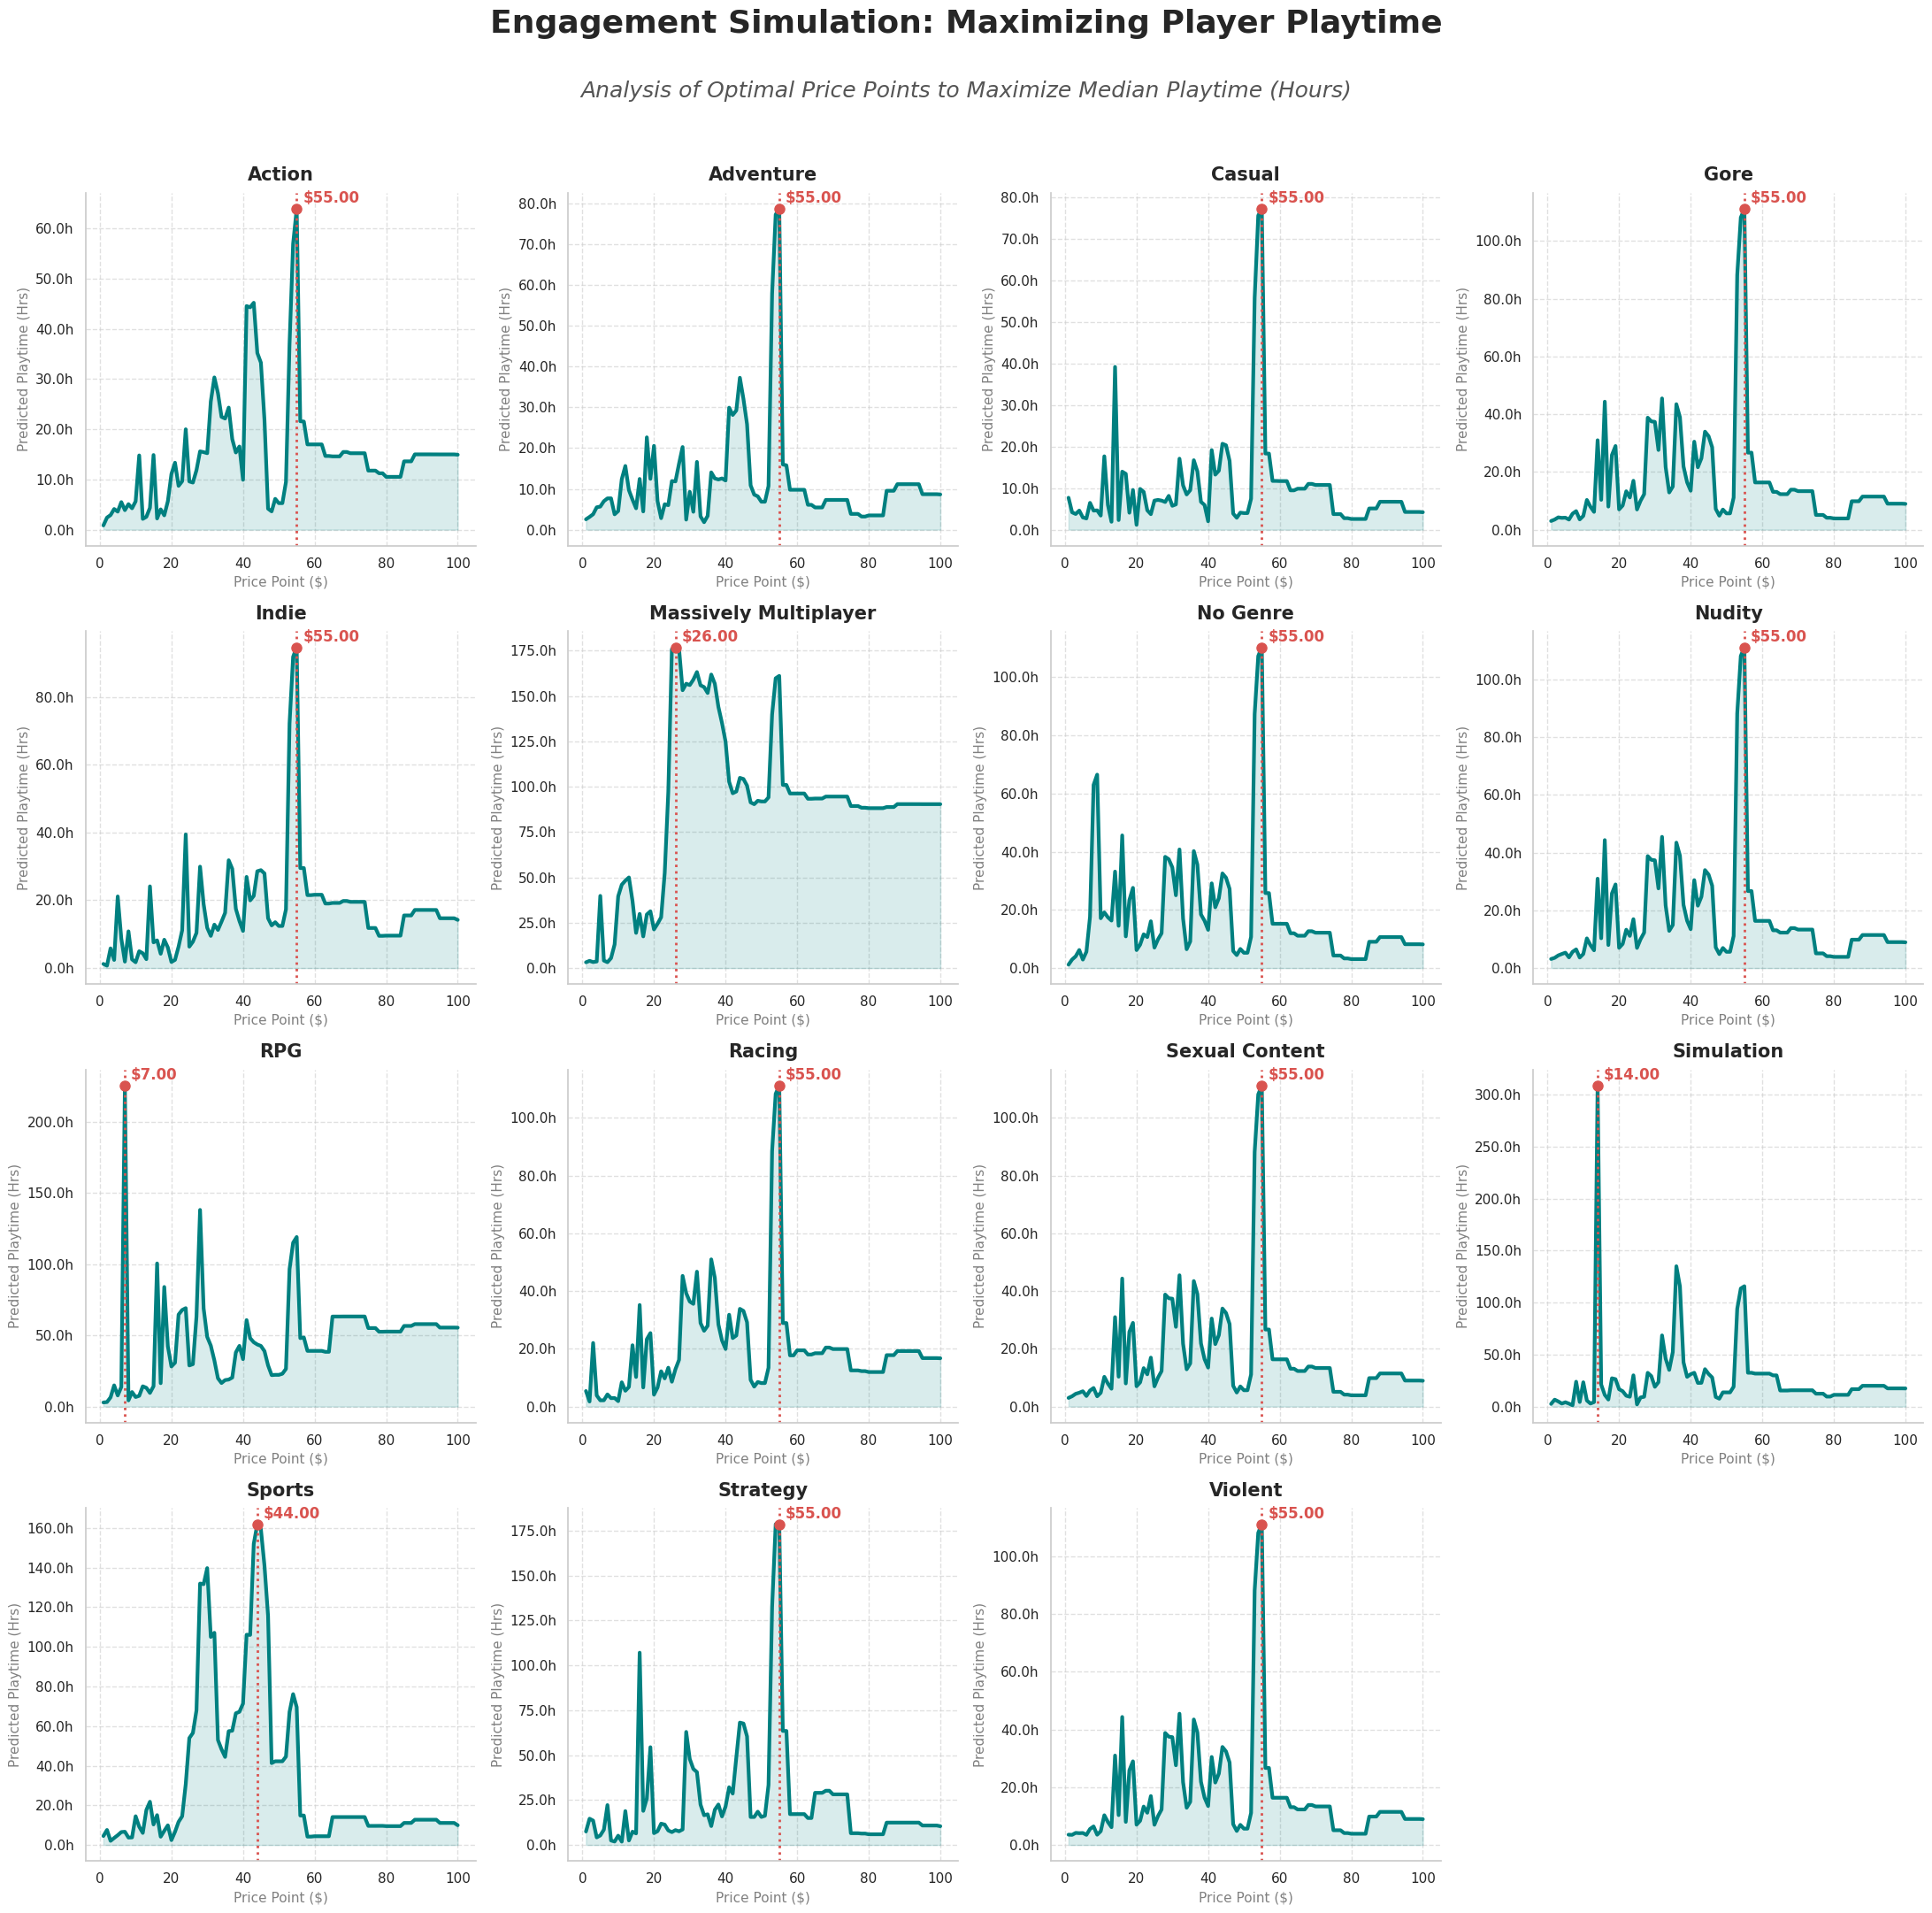

In [15]:
print("--- Training the Playtime Optimization Model ---")

# 1. Define our Target (y_playtime) in Hours
# We dynamically check for the column name just in case, and divide by 60 to get hours
playtime_col = 'median_playtime_forever' if 'median_playtime_forever' in df_active_games.columns else 'average_playtime_forever'
y_playtime = (df_active_games[playtime_col] / 60.0).copy().reset_index(drop=True)

# 2. Split into Training and Testing datasets
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X, y_playtime, test_size=0.2, random_state=42)

# 3. Initialize and Train the Playtime Random Forest
rf_model_playtime = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_playtime.fit(X_train_p, y_train_p)

# Evaluate the Model
preds_p = rf_model_playtime.predict(X_test_p)
mae_p = mean_absolute_error(y_test_p, preds_p)
print(f"Playtime Model successfully trained! Mean Absolute Error: {mae_p:,.1f} hours")

print("\n--- Simulating the Playtime Sweet Spot for ALL Genres ---")

# Setup the grid
genre_cols = [col for col in X.columns if col.startswith('Genre_')]
num_genres = len(genre_cols)
cols = 4
rows = (num_genres + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(22, 5 * rows))
axes = axes.flatten()

sim_prices = np.arange(1, 101, 1)

# Loop through genres and simulate
for i, target_genre in enumerate(genre_cols):
    ax = axes[i]
    
    # Create simulation data
    sim_data = pd.DataFrame(0, index=np.arange(len(sim_prices)), columns=X.columns)
    sim_data['price'] = sim_prices
    sim_data['Early_Access'] = 0  
    sim_data[target_genre] = 1    
    
    # Predict Playtime using the NEW model
    sim_data['Predicted_Playtime'] = rf_model_playtime.predict(sim_data)
    
    # Find Sweet Spot for Max Playtime
    optimal_idx = sim_data['Predicted_Playtime'].idxmax()
    optimal_price = sim_data.loc[optimal_idx, 'price']
    max_playtime = sim_data.loc[optimal_idx, 'Predicted_Playtime']
    
    # Plotting the curve and area under curve (Using teal to visually distinguish)
    ax.plot(sim_data['price'], sim_data['Predicted_Playtime'], color='teal', linewidth=3)
    ax.fill_between(sim_data['price'], sim_data['Predicted_Playtime'], color='teal', alpha=0.15)
    
    # Plotting the sweet spot marker and line
    ax.axvline(optimal_price, color='#d9534f', linestyle=':', linewidth=2)
    ax.plot(optimal_price, max_playtime, marker='o', markersize=8, color='#d9534f')
    
    # Annotate sweet spot cleanly instead of using a legend
    ax.annotate(f'${optimal_price:.2f}', xy=(optimal_price, max_playtime), 
                xytext=(5, 5), textcoords='offset points', 
                color='#d9534f', fontweight='bold', fontsize=12)
    
    # Labeling
    clean_name = target_genre.replace('Genre_', '')
    ax.set_title(clean_name, fontsize=15, fontweight='bold', pad=10)
    ax.set_xlabel('Price Point ($)', fontsize=11, color='gray')
    ax.set_ylabel('Predicted Playtime (Hrs)', fontsize=11, color='gray')
    ax.grid(True, alpha=0.6, linestyle='--')
    
    # Formatter for hours
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, loc: f"{x:.1f}h"))

# Cleanup empty subplots
for j in range(num_genres, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

# Title and Subtitle
fig.suptitle('Engagement Simulation: Maximizing Player Playtime', 
             fontsize=26, fontweight='bold', y=1.08)
fig.text(0.5, 1.03, 'Analysis of Optimal Price Points to Maximize Median Playtime (Hours)', 
         ha='center', fontsize=18, style='italic', color='#555555')

# Save and display
os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/pricing_sweet_spot_playtime_all_genres.png', bbox_inches='tight', dpi=300)
print("\nSimulation Complete! Plot saved to 'graphs/pricing_sweet_spot_playtime_all_genres.png'")

plt.show()